# Model Training
## Health Insurance Fraud Detection System

**Purpose:** Train and evaluate four unsupervised anomaly detection models:
1. Isolation Forest
2. One-Class SVM
3. Local Outlier Factor (LOF)
4. Autoencoder (using Keras)

**Ensemble:** Combine all four models using score averaging.

---

## 1. Setup and Imports


In [6]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn models
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score, 
    roc_auc_score, average_precision_score, roc_curve
)

# Keras
import keras
from keras import layers, models

# Utilities
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ All imports successful!")

✅ All imports successful!


## 2. Load Preprocessed Data

In [7]:
# Load processed data from the EDA notebook
X_train = np.load('../data/processed/X_train.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')

# Load feature names
with open('../data/processed/feature_names.txt', 'r') as f:
    feature_names = f.read().splitlines()

# Load scaler if needed
with open('../data/processed/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

print(f"Training set: {X_train.shape[0]:,} samples, {X_train.shape[1]} features")
print(f"Test set: {X_test.shape[0]:,} samples, {X_test.shape[1]} features")
print(f"Training anomaly rate: {y_train.mean():.2%}")
print(f"Test anomaly rate: {y_test.mean():.2%}")
print(f"Features: {feature_names}")

Training set: 8,000 samples, 10 features
Test set: 2,000 samples, 10 features
Training anomaly rate: 3.94%
Test anomaly rate: 3.95%
Features: ['cpt_procedure_code', 'billed_amount', 'amount_bucket', 'year', 'month', 'day_of_week', 'day_of_month', 'quarter', 'icd10_diagnosis_code_freq', 'claim_status_freq']


## 3. Evaluation Function

Define a function to evaluate anomaly detection models using:
- **Precision@100**: Primary metric - proportion of true anomalies in top 100
- **AUC-ROC**: Threshold-independent holistic measure
- **AUC-PR**: Better for imbalanced data
- **F1-Score**: Balance between precision and recall

In [8]:
def evaluate_model(y_true, scores, k=100):
    """
    Evaluate anomaly detection model performance.
    
    Parameters:
    -----------
    y_true : array
        True labels (0 = normal, 1 = anomaly)
    scores : array
        Anomaly scores (higher = more anomalous)
    k : int
        Number of top anomalies to consider for Precision@k
    
    Returns:
    --------
    dict: Evaluation metrics
    """
    # Get top k predictions
    top_k_indices = np.argsort(scores)[-k:]
    y_pred_top = np.zeros(len(y_true))
    y_pred_top[top_k_indices] = 1
    
    # Compute metrics
    precision_k = precision_score(y_true, y_pred_top)
    recall_k = recall_score(y_true, y_pred_top)
    f1_k = f1_score(y_true, y_pred_top)
    
    auc_roc = roc_auc_score(y_true, scores)
    auc_pr = average_precision_score(y_true, scores)
    
    return {
        'precision@100': precision_k,
        'recall@100': recall_k,
        'f1@100': f1_k,
        'auc_roc': auc_roc,
        'auc_pr': auc_pr
    }

def normalise_scores(scores):
    """Normalise scores to [0, 1] range."""
    return (scores - scores.min()) / (scores.max() - scores.min() + 1e-10)

print("✅ Evaluation functions defined!")

✅ Evaluation functions defined!


## 4. Train Models

### 4.1 Isolation Forest

Isolation Forest isolates anomalies by randomly selecting features and split values. Anomalies require fewer splits to isolate.

In [9]:
print("=" * 60)
print("Training Isolation Forest...")
print("=" * 60)

# Train Isolation Forest
if_model = IsolationForest(
    contamination=0.05,
    random_state=42,
    n_estimators=100,
    max_samples='auto'
)

if_model.fit(X_train)
if_scores = -if_model.score_samples(X_test)  # Higher = more anomalous

# Normalise scores
if_scores_norm = normalise_scores(if_scores)

print(f"Isolation Forest trained!")
print(f"Score range: [{if_scores_norm.min():.4f}, {if_scores_norm.max():.4f}]")

Training Isolation Forest...
Isolation Forest trained!
Score range: [0.0000, 1.0000]


### 4.2 One-Class SVM

One-Class SVM learns a decision boundary that encloses normal data points. Points outside the boundary are anomalies.

In [10]:
print("=" * 60)
print("Training One-Class SVM...")
print("=" * 60)

# Train One-Class SVM
ocsvm_model = OneClassSVM(
    kernel='rbf',
    gamma='scale',
    nu=0.05
)

ocsvm_model.fit(X_train)
ocsvm_scores = -ocsvm_model.decision_function(X_test)  # Higher = more anomalous

# Normalise scores
ocsvm_scores_norm = normalise_scores(ocsvm_scores)

print(f"One-Class SVM trained!")
print(f"Score range: [{ocsvm_scores_norm.min():.4f}, {ocsvm_scores_norm.max():.4f}]")

Training One-Class SVM...
One-Class SVM trained!
Score range: [0.0000, 1.0000]


### 4.3 Local Outlier Factor (LOF)

LOF measures the local density deviation of a point relative to its neighbours. Lower density = more anomalous.

In [11]:
print("=" * 60)
print("Training Local Outlier Factor...")
print("=" * 60)

# Train LOF
lof_model = LocalOutlierFactor(
    contamination=0.05,
    n_neighbors=20,
    novelty=True  # Use novelty=True for predicting on new data
)

lof_model.fit(X_train)
lof_scores = -lof_model.score_samples(X_test)  # Higher = more anomalous

# Normalise scores
lof_scores_norm = normalise_scores(lof_scores)

print(f"Local Outlier Factor trained!")
print(f"Score range: [{lof_scores_norm.min():.4f}, {lof_scores_norm.max():.4f}]")

Training Local Outlier Factor...
Local Outlier Factor trained!
Score range: [0.0000, 1.0000]


### 4.4 Autoencoder

Autoencoder is a neural network trained to reconstruct its input. High reconstruction error indicates an anomaly.

In [12]:
print("=" * 60)
print("Training Autoencoder...")
print("=" * 60)

# Build autoencoder architecture
input_dim = X_train.shape[1]
encoding_dim = 8

autoencoder = models.Sequential([
    # Encoder
    layers.Dense(64, activation='relu', input_shape=(input_dim,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(encoding_dim, activation='relu'),
    # Decoder
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])

# Compile
autoencoder.compile(optimizer='adam', loss='mse')

# Display model architecture
autoencoder.summary()

# Train
print("\nTraining autoencoder...")
history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose="1"
)

# Get reconstruction error as anomaly score
reconstructions = autoencoder.predict(X_test, verbose=0)
ae_scores = np.mean(np.square(X_test - reconstructions), axis=1)

# Normalise scores
ae_scores_norm = normalise_scores(ae_scores)

print(f"\nAutoencoder trained!")
print(f"Score range: [{ae_scores_norm.min():.4f}, {ae_scores_norm.max():.4f}]")


Training Autoencoder...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,098 (23.82 KB)

 Trainable params: 6,098 (23.82 KB)

 Non-trainable params: 0 (0.00 B)


Training autoencoder...
Epoch 1/50
Epoch 2/50
Epoch 3/50
Epoch 4/50
Epoch 5/50
Epoch 6/50
Epoch 7/50
Epoch 8/50
Epoch 9/50
Epoch 10/50
Epoch 11/50
Epoch 12/50
Epoch 13/50
Epoch 14/50
Epoch 15/50
Epoch 16/50
Epoch 17/50
Epoch 18/50
Epoch 19/50
Epoch 20/50
Epoch 21/50
Epoch 22/50
Epoch 23/50
Epoch 24/50
Epoch 25/50
Epoch 26/50
Epoch 27/50
Epoch 28/50
Epoch 29/50
Epoch 30/50
Epoch 31/50
Epoch 32/50
Epoch 33/50
Epoch 34/50
Epoch 35/50
Epoch 36/50
Epoch 37/50
Epoch 38/50
Epoch 39/50
Epoch 40/50
Epoch 41/50
Epoch 42/50
Epoch 43/50
Epoch 44/50
Epoch 45/50
Epoch 46/50
Epoch 47/50
Epoch 48/50
Epoch 49/50
Epoch 50/50

Autoencoder trained!
Score range: [0.0000, 1.0000]


### 4.5 Training History Visualization

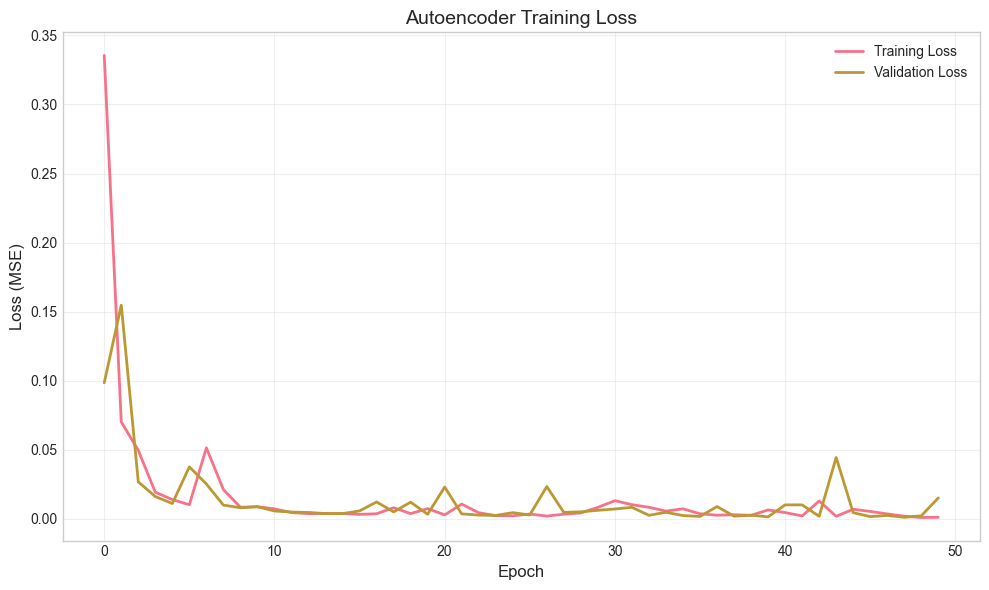

In [14]:
# Plot training loss
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (MSE)', fontsize=12)
ax.set_title('Autoencoder Training Loss', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('../figures/autoencoder_training_loss.png', dpi=300)
plt.show()

## 5. Ensemble Scoring

Combine all four models using score averaging.

In [15]:
print("=" * 60)
print("Computing Ensemble Scores...")
print("=" * 60)

# Collect all normalised scores
all_scores = {
    'Isolation Forest': if_scores_norm,
    'One-Class SVM': ocsvm_scores_norm,
    'Local Outlier Factor': lof_scores_norm,
    'Autoencoder': ae_scores_norm
}

# Ensemble (average of normalised scores)
ensemble_scores = np.mean(list(all_scores.values()), axis=0)

print(f"Ensemble score range: [{ensemble_scores.min():.4f}, {ensemble_scores.max():.4f}]")


Computing Ensemble Scores...
Ensemble score range: [0.0401, 0.8084]


### 6.1 Performance Metrics

In [16]:
print("=" * 60)
print("Model Performance Comparison")
print("=" * 60)

# Evaluate all models
results = {}
for name, scores in all_scores.items():
    results[name] = evaluate_model(y_test, scores, k=100)

# Add ensemble
results['Ensemble'] = evaluate_model(y_test, ensemble_scores, k=100)

# Create DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

# Sort by precision@100
results_df = results_df.sort_values('precision@100', ascending=False)

print(results_df)

# Save results
results_df.to_csv('../data/processed/model_results.csv')
print("\nResults saved to: ../data/processed/model_results.csv")

Model Performance Comparison
                      precision@100  recall@100  f1@100  auc_roc  auc_pr
Autoencoder                    0.12      0.1519  0.1341   0.7463  0.1059
Isolation Forest               0.08      0.1013  0.0894   0.7241  0.0869
Ensemble                       0.06      0.0759  0.0670   0.7401  0.0902
One-Class SVM                  0.05      0.0633  0.0559   0.6808  0.0730
Local Outlier Factor           0.02      0.0253  0.0223   0.5464  0.0443

Results saved to: ../data/processed/model_results.csv


### 6.2 Best Model Identification

In [17]:
print("=" * 60)
print("Best Model Summary")
print("=" * 60)

best_precision = results_df['precision@100'].idxmax()
best_auc_roc = results_df['auc_roc'].idxmax()
best_auc_pr = results_df['auc_pr'].idxmax()

print(f"Best Precision@100: {best_precision} ({results_df.loc[best_precision, 'precision@100']:.4f})")
print(f"Best AUC-ROC: {best_auc_roc} ({results_df.loc[best_auc_roc, 'auc_roc']:.4f})")
print(f"Best AUC-PR: {best_auc_pr} ({results_df.loc[best_auc_pr, 'auc_pr']:.4f})")

Best Model Summary
Best Precision@100: Autoencoder (0.1200)
Best AUC-ROC: Autoencoder (0.7463)
Best AUC-PR: Autoencoder (0.1059)


### 6.3 ROC Curves

FileNotFoundError: [Errno 2] No such file or directory: '../figures/roc_curves.png'

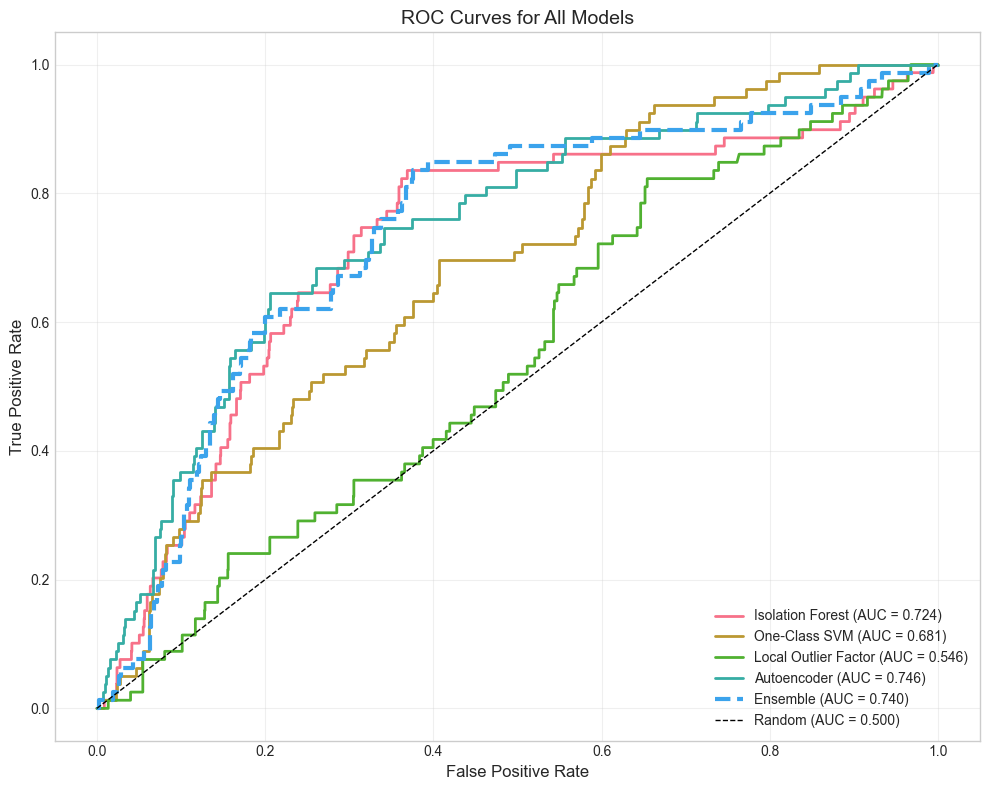

In [18]:
plt.figure(figsize=(10, 8))

# Plot ROC curves for all models
for name, scores in all_scores.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = results[name]['auc_roc']
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

# Add ensemble
fpr, tpr, _ = roc_curve(y_test, ensemble_scores)
auc = results['Ensemble']['auc_roc']
plt.plot(fpr, tpr, label=f'Ensemble (AUC = {auc:.3f})', linewidth=3, linestyle='--')

# Random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves for All Models', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/roc_curves.png', dpi=300)
plt.show()